<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/DL_Lab_02_6th_Jan_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Experiment 2: Feed Forward Network

# 1. Define Functions (Activation & Propagation)
# definition of sigmoidal Activation Function
import math

def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

# Evaluate the output of single unit (neuron)
def neuron_output(weights, inputs):
    activation = weights[0] # bias
    for i in range(len(inputs)):
        activation += weights[i + 1] * inputs[i]
    return sigmoid(activation)

def forward_propagate(ffnet_layers, row):
    inputs = row[:-1] # exclude label
    print('input:', row)
    for layer in ffnet_layers:
        new_inputs = []
        i = 0;

        for neuron in layer:
            output = neuron_output(neuron, inputs)
            new_inputs.append(output)

        inputs = new_inputs

    return inputs[0] # final output


# 2. Define Network Weights & Dataset

# Create a Feed Forward Network (ffnet) with one hidded Layer having two neurons and outlayer with one neuron.
ffnet_layers = [
    [   # input layer to Hidden layer
        [0.1, 0.2, -0.3],   # neuron 1: bias, w1, w2
        [-0.1, 0.4, 0.1]    # neuron 2: bias, w1, w2
    ],
    [   # hidden layer to Output layer
        [0.05, 0.3, -0.2]   # bias, w_hidden1, w_hidden2
    ]
]

dataset = [
    [1,2,0],
    [5,4,1],
    [2,1,0],
    [3,3,1],
    [7,2,1],
    [5,2,1],
    [6,1,1],
    [8,-0.2,1],
    [7,3,1]
]


# 3. Run Forward Propagation (Testing)

for row in dataset:
    output = forward_propagate(ffnet_layers, row)
    prediction = 1 if output >= 0.5 else 0
    print(f"Expected={row[-1]}, Predicted={prediction}, Output={output:.3f}")



input: [1, 2, 0]
Expected=0, Predicted=1, Output=0.513
input: [5, 4, 1]
Expected=1, Predicted=1, Output=0.503
input: [2, 1, 0]
Expected=0, Predicted=1, Output=0.519
input: [3, 3, 1]
Expected=1, Predicted=1, Output=0.506
input: [7, 2, 1]
Expected=1, Predicted=1, Output=0.518
input: [5, 2, 1]
Expected=1, Predicted=1, Output=0.515
input: [6, 1, 1]
Expected=1, Predicted=1, Output=0.521
input: [8, -0.2, 1]
Expected=1, Predicted=1, Output=0.529
input: [7, 3, 1]
Expected=1, Predicted=1, Output=0.513


Running Experiment 2: Regularization Deep Dive...
Training with NO Regularization...
Training with L2 Regularization (Weight Decay)...
Training with L1 Regularization (Lasso)...

--- RESULTS ---
Average Weight Size (None): 1.3095 (Allowed to get big)
Average Weight Size (L2):   0.0065   (Shrunk!)
Average Weight Size (L1):   0.0197   (Shrunk!)


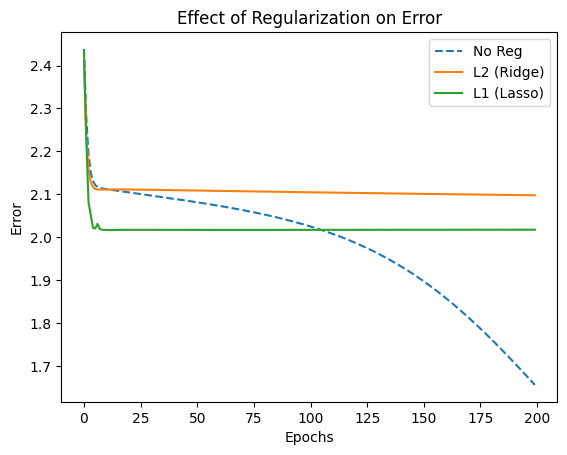

In [1]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Standard Feed Forward)
# ==========================================
def sigmoid(x):
    # Clip x to avoid overflow errors
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Initialize with slightly larger random weights to test Regularization
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# ==========================================
# 2. THE REGULARIZERS (The "Different Techniques")
# ==========================================
def update_weights_regularized(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]

        for neuron in network[i]:
            for j in range(len(inputs)):
                # 1. Calculate Standard Gradient
                gradient = neuron['delta'] * inputs[j]

                # 2. Calculate Regularization Term (The "Pull" back to zero)
                weight = neuron['weights'][j]
                regularization_term = 0.0

                if reg_type == 'l1':
                    # L1 pushes by a constant amount towards zero
                    sign = 1 if weight > 0 else -1
                    regularization_term = lambda_val * sign

                elif reg_type == 'l2':
                    # L2 pushes harder if the weight is huge
                    regularization_term = lambda_val * weight

                # 3. Update: Weight = Old - LearningRate * (Gradient - Penalty)
                # Note: We SUBTRACT gradient, but usually ADD penalty logic.
                # Let's stick to standard update: w = w + (lr * delta) - (lr * penalty)

                neuron['weights'][j] += l_rate * gradient

                # Apply the penalty (shrink the weight)
                neuron['weights'][j] -= l_rate * regularization_term

            # Update Bias (Usually we do NOT regularize bias, but we update it normally)
            neuron['weights'][-1] += l_rate * neuron['delta']

# ==========================================
# 3. TRAINING & MANUAL CHECK
# ==========================================
def train_network(reg_type, dataset, n_epoch, lambda_val):
    random.seed(42) # Fixed seed so all networks start same
    network = initialize_network(2, 4, 1) # Larger network to encourage overfitting
    history = []

    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights_regularized(network, row, 0.5, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)

    # Return the average weight size (To prove Regularization worked)
    total_weight_magnitude = 0
    count = 0
    for layer in network:
        for neuron in layer:
            for w in neuron['weights'][:-1]: # Exclude bias
                total_weight_magnitude += abs(w)
                count += 1
    avg_weight = total_weight_magnitude / count

    return history, avg_weight

# ==========================================
# 4. EXECUTION
# ==========================================
# Dataset: A noisy version of XOR (harder to learn perfectly)
dataset = [
    [0,0,0], [0,0.1,0],
    [0,1,1], [0.1,1,1],
    [1,0,1], [1,0.1,1],
    [1,1,0], [0.9,0.9,0]
]

print("Running Experiment 2: Regularization Deep Dive...")

# 1. No Regularization
print("Training with NO Regularization...")
hist_none, avg_none = train_network('none', dataset, 200, 0.0)

# 2. L2 Regularization
print("Training with L2 Regularization (Weight Decay)...")
hist_l2, avg_l2 = train_network('l2', dataset, 200, 0.05)

# 3. L1 Regularization
print("Training with L1 Regularization (Lasso)...")
hist_l1, avg_l1 = train_network('l1', dataset, 200, 0.05)

# Report Results
print("\n--- RESULTS ---")
print(f"Average Weight Size (None): {avg_none:.4f} (Allowed to get big)")
print(f"Average Weight Size (L2):   {avg_l2:.4f}   (Shrunk!)")
print(f"Average Weight Size (L1):   {avg_l1:.4f}   (Shrunk!)")

# Plot
plt.plot(hist_none, label='No Reg', linestyle='--')
plt.plot(hist_l2, label='L2 (Ridge)')
plt.plot(hist_l1, label='L1 (Lasso)')
plt.title('Effect of Regularization on Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.show()

Running Experiment 2: Regularization Deep Dive...
Training with NO Regularization...
Training with L2 Regularization (Weight Decay)...
Training with L1 Regularization (Lasso)...

--- RESULTS ---
Average Weight Size (None): 1.3095 (Allowed to get big)
Average Weight Size (L2):   0.0074   (Shrunk!)
Average Weight Size (L1):   0.1595   (Shrunk!)


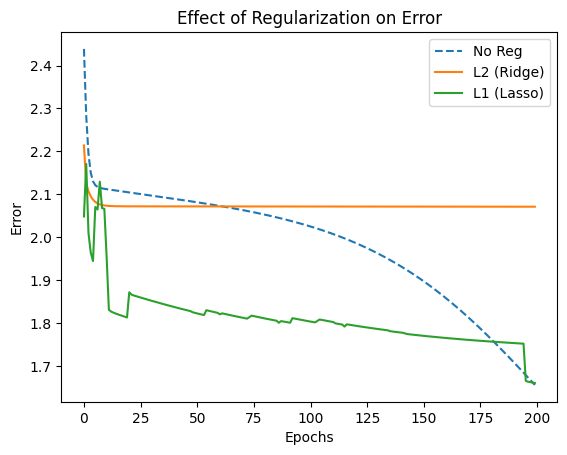

In [2]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. BASE ENGINE (Standard Feed Forward)
# ==========================================
def sigmoid(x):
    # Clip x to avoid overflow errors
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Initialize with slightly larger random weights to test Regularization
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# ==========================================
# 2. THE REGULARIZERS (The "Different Techniques")
# ==========================================
def update_weights_regularized(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]

        for neuron in network[i]:
            for j in range(len(inputs)):
                # 1. Calculate Standard Gradient
                gradient = neuron['delta'] * inputs[j]

                # 2. Calculate Regularization Term (The "Pull" back to zero)
                weight = neuron['weights'][j]
                regularization_term = 0.0

                if reg_type == 'l1':
                    # L1 pushes by a constant amount towards zero
                    sign = 1 if weight > 0 else -1
                    regularization_term = lambda_val * sign

                elif reg_type == 'l2':
                    # L2 pushes harder if the weight is huge
                    regularization_term = lambda_val * weight

                # 3. Update: Weight = Old - LearningRate * (Gradient - Penalty)
                # Note: We SUBTRACT gradient, but usually ADD penalty logic.
                # Let's stick to standard update: w = w + (lr * delta) - (lr * penalty)

                neuron['weights'][j] += l_rate * gradient

                # Apply the penalty (shrink the weight)
                neuron['weights'][j] -= l_rate * regularization_term

            # Update Bias (Usually we do NOT regularize bias, but we update it normally)
            neuron['weights'][-1] += l_rate * neuron['delta']

# ==========================================
# 3. TRAINING & MANUAL CHECK
# ==========================================
def train_network(reg_type, dataset, n_epoch, lambda_val):
    random.seed(42) # Fixed seed so all networks start same
    network = initialize_network(2, 4, 1) # Larger network to encourage overfitting
    history = []

    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights_regularized(network, row, 0.5, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)

    # Return the average weight size (To prove Regularization worked)
    total_weight_magnitude = 0
    count = 0
    for layer in network:
        for neuron in layer:
            for w in neuron['weights'][:-1]: # Exclude bias
                total_weight_magnitude += abs(w)
                count += 1
    avg_weight = total_weight_magnitude / count

    return history, avg_weight

# ==========================================
# 4. EXECUTION
# ==========================================
# Dataset: A noisy version of XOR (harder to learn perfectly)
dataset = [
    [0,0,0], [0,0.1,0],
    [0,1,1], [0.1,1,1],
    [1,0,1], [1,0.1,1],
    [1,1,0], [0.9,0.9,0]
]

print("Running Experiment 2: Regularization Deep Dive...")

# 1. No Regularization
print("Training with NO Regularization...")
hist_none, avg_none = train_network('none', dataset, 200, 0.0)

# 2. L2 Regularization
print("Training with L2 Regularization (Weight Decay)...")
hist_l2, avg_l2 = train_network('l2', dataset, 200, 0.5)

# 3. L1 Regularization
print("Training with L1 Regularization (Lasso)...")
hist_l1, avg_l1 = train_network('l1', dataset, 200, 0.5)

# Report Results
print("\n--- RESULTS ---")
print(f"Average Weight Size (None): {avg_none:.4f} (Allowed to get big)")
print(f"Average Weight Size (L2):   {avg_l2:.4f}   (Shrunk!)")
print(f"Average Weight Size (L1):   {avg_l1:.4f}   (Shrunk!)")

# Plot
plt.plot(hist_none, label='No Reg', linestyle='--')
plt.plot(hist_l2, label='L2 (Ridge)')
plt.plot(hist_l1, label='L1 (Lasso)')
plt.title('Effect of Regularization on Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.show()